<a href="https://colab.research.google.com/github/MonikSense/GAAFET/blob/main/GAAFETFinal3ff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Gate  Direction   Lg   W    SS           Ion   Vov
0     1          1   55  18  62.0  2.300000e-07  0.45
1     0          1  200  70  70.0  1.000000e-05  1.20
2     0          1  170  40  50.0  1.000000e-08  1.20
3     1          0  180   5  63.0  8.000000e-04  0.60
4     1          0  200   7  30.0  2.000000e-06  0.50
Original size: (47, 7)
Augmented size: (188, 7)
Linear Regression Prediction Efficiency: -21555.04%


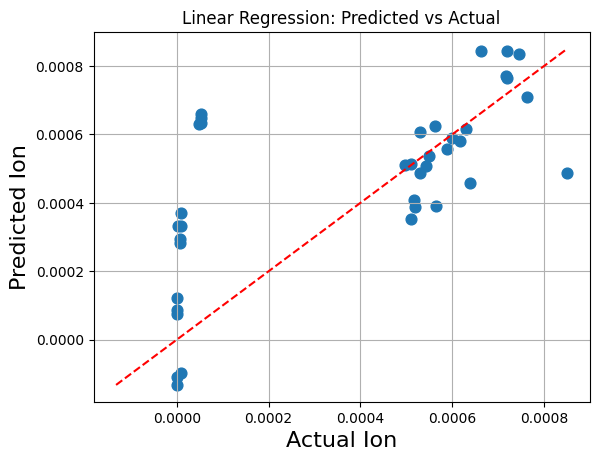

Random Forest Prediction Efficiency: -2155.69%


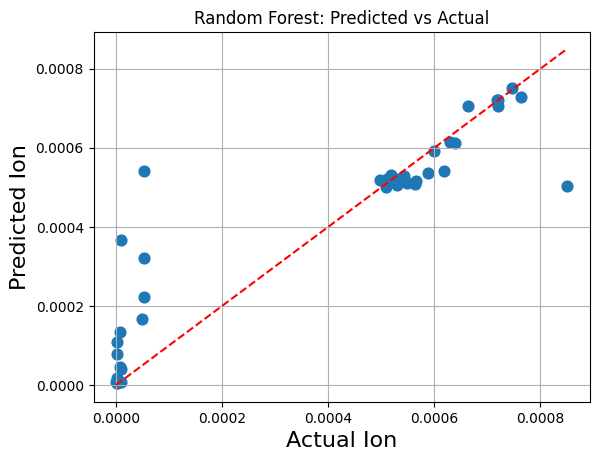

XGBoost Prediction Efficiency: -49405.36%


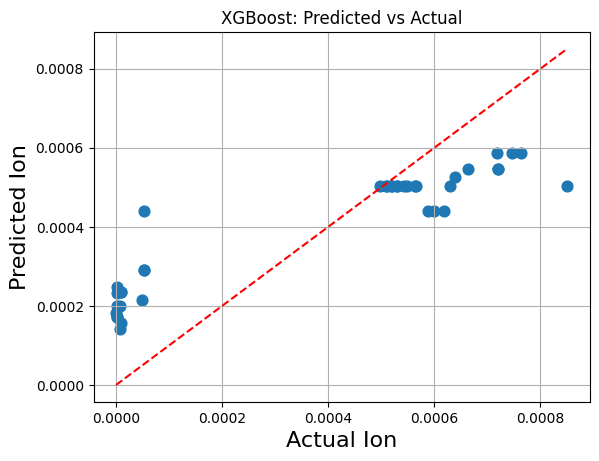

SVR Prediction Efficiency: -177814.50%


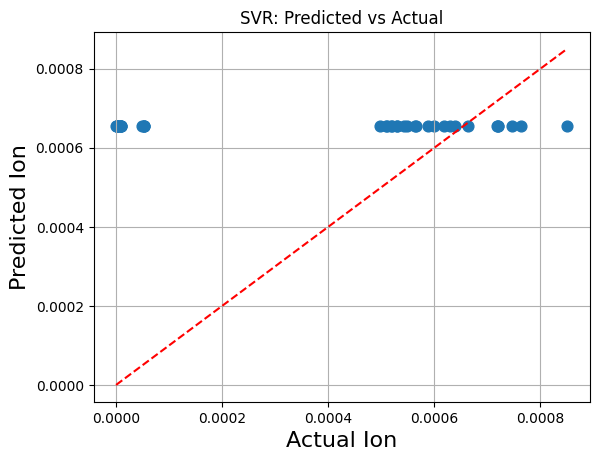

KNN Prediction Efficiency: -1235.97%


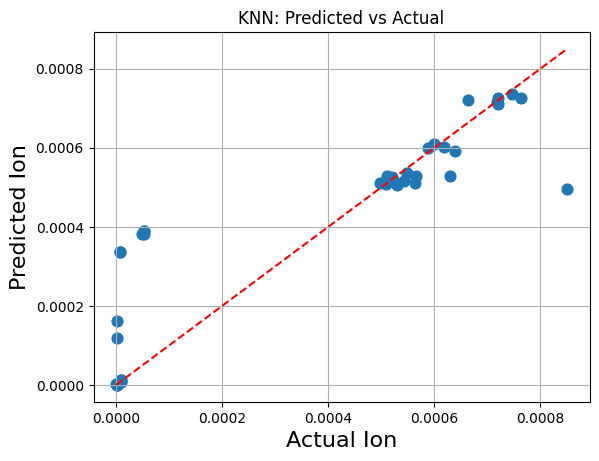

Gradient Boosting Prediction Efficiency: -2450.43%


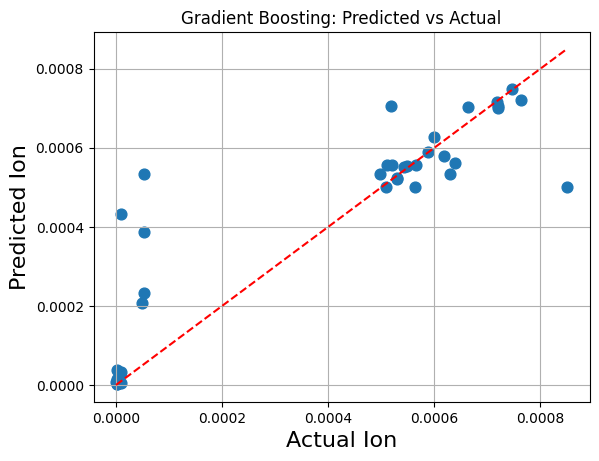


Model Comparison:
               Model        R2      RMSE
0  Linear Regression  0.330226  0.000246
1      Random Forest  0.808106  0.000132
2            XGBoost  0.679638  0.000170
3                SVR -0.846262  0.000409
4                KNN  0.752822  0.000150
5  Gradient Boosting  0.776059  0.000142

Classification Accuracy: 0.9210526315789473


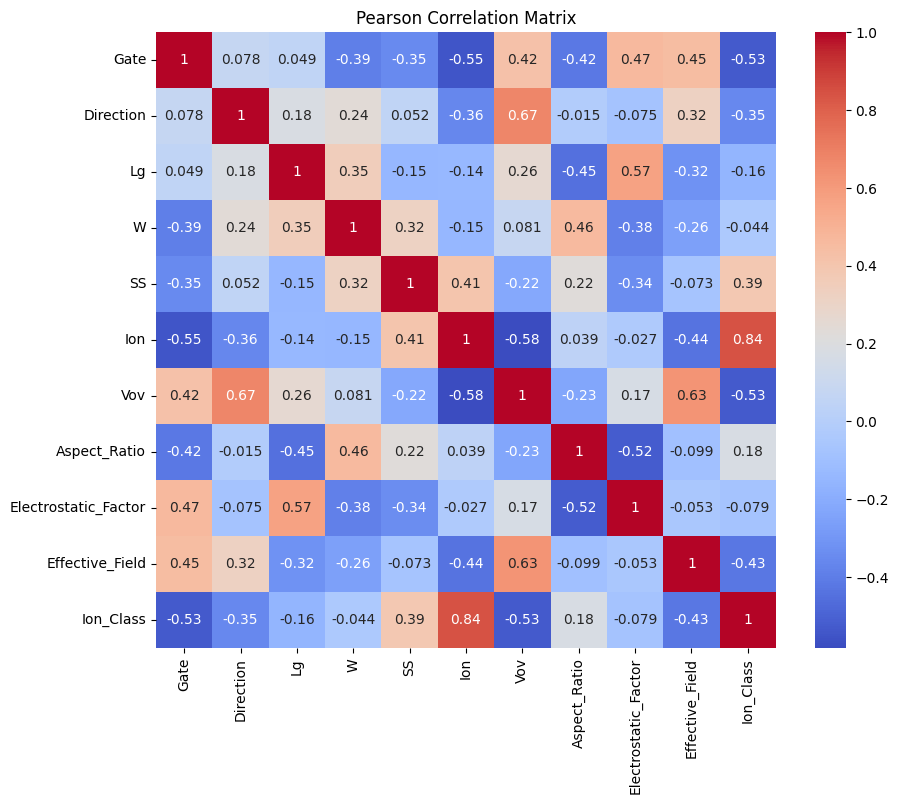

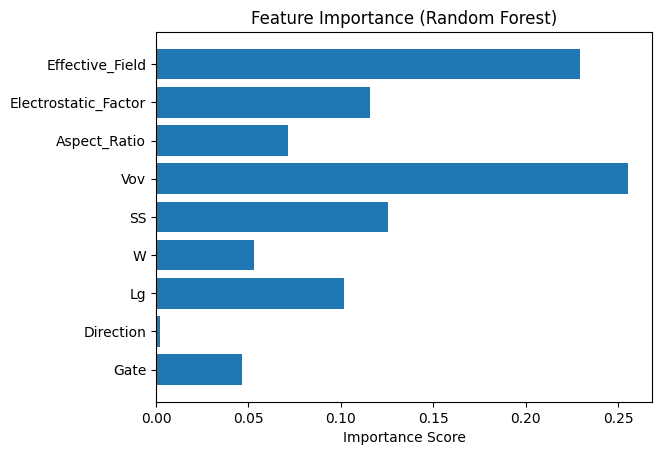

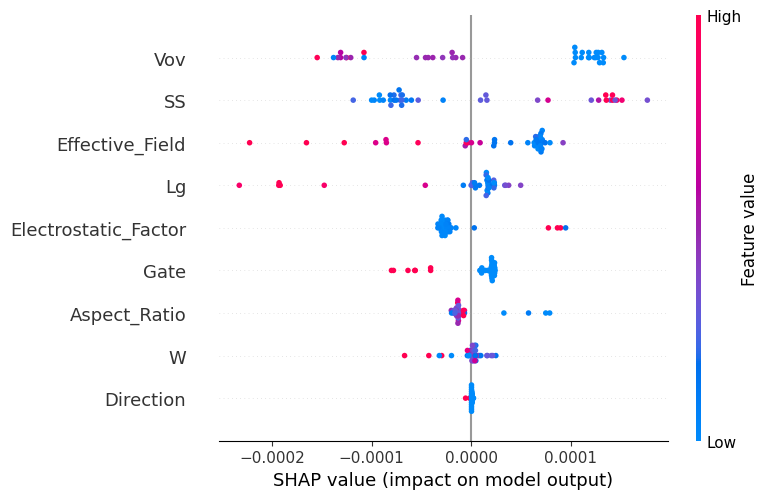

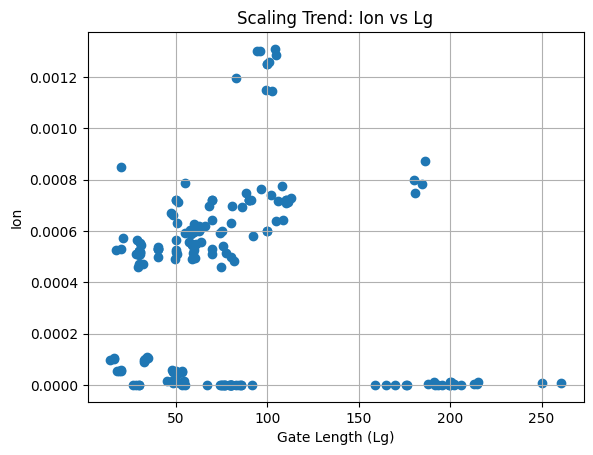

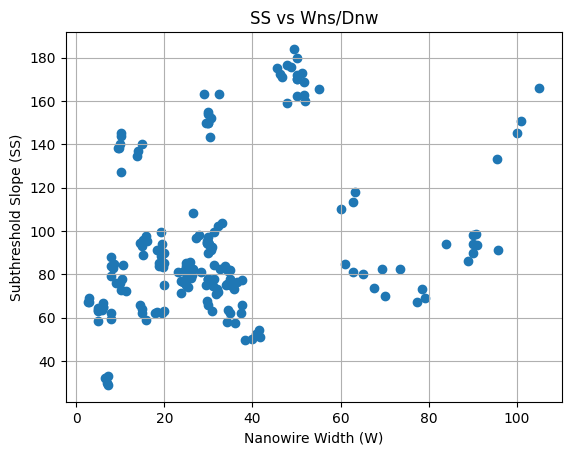

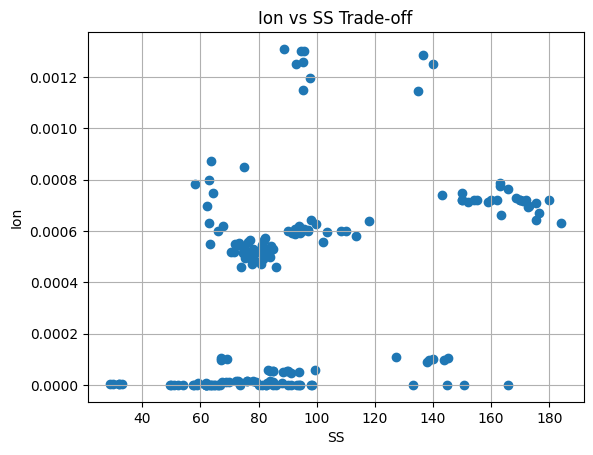

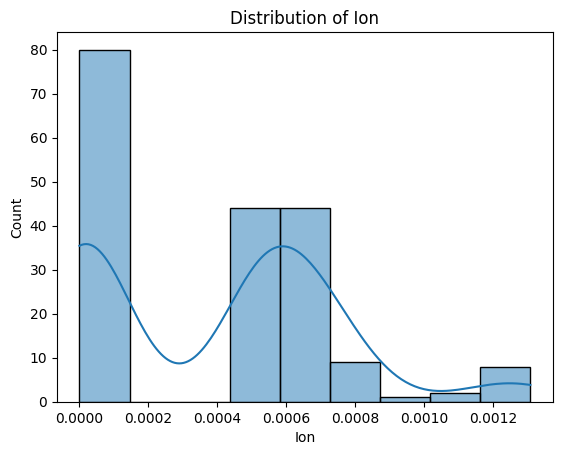

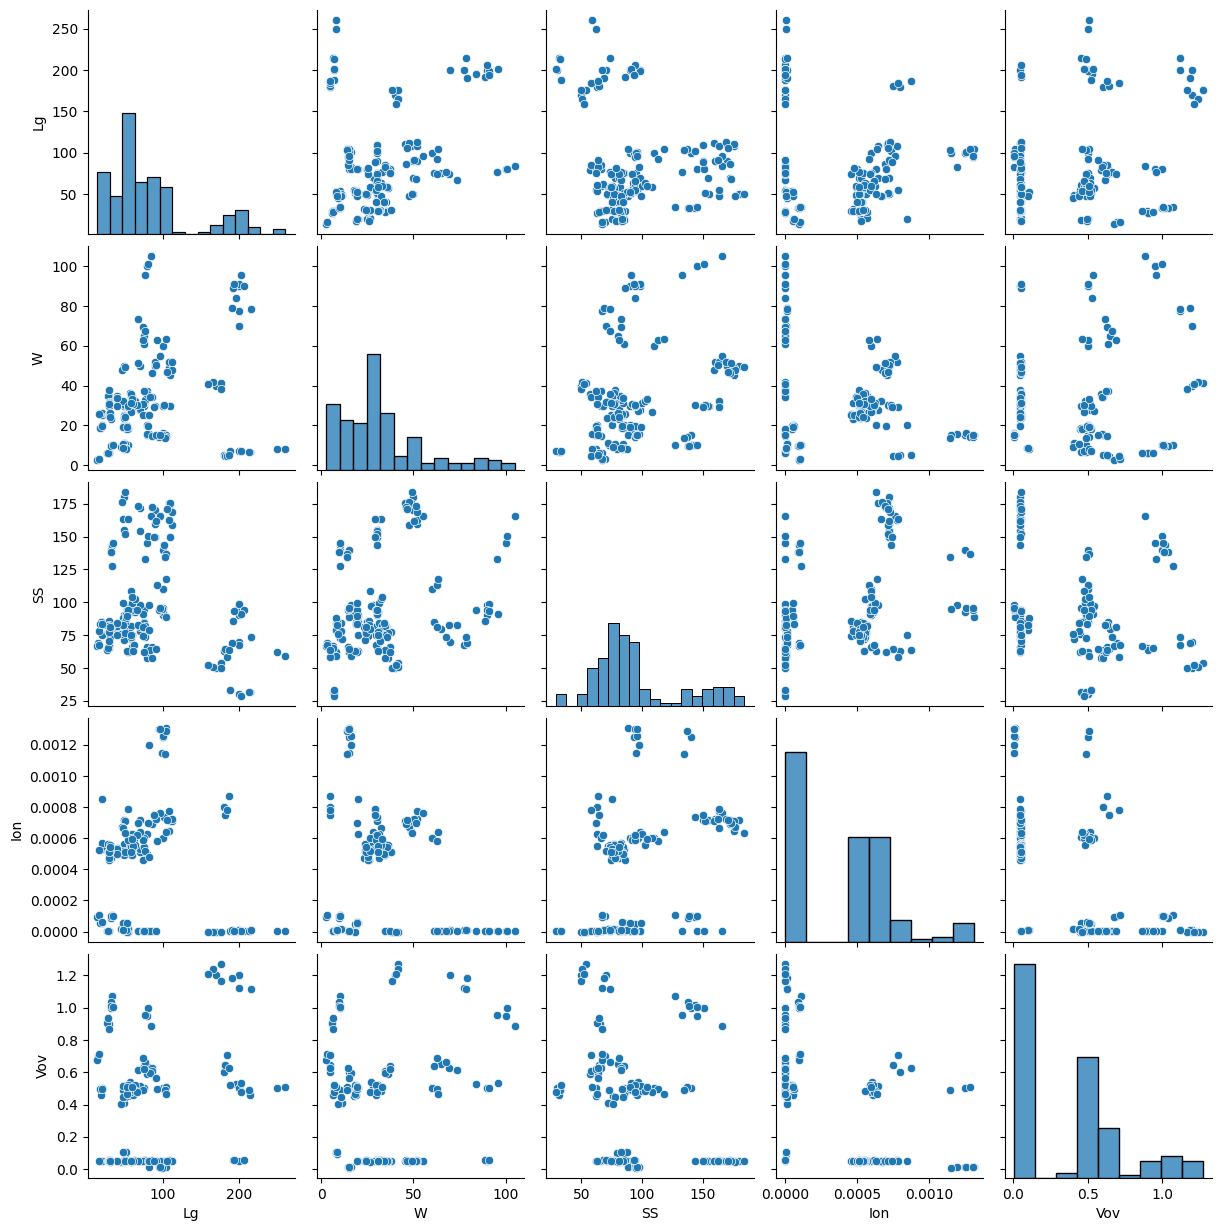


Running model for: Ion
R2 Score (Ion): 0.9737932907996639


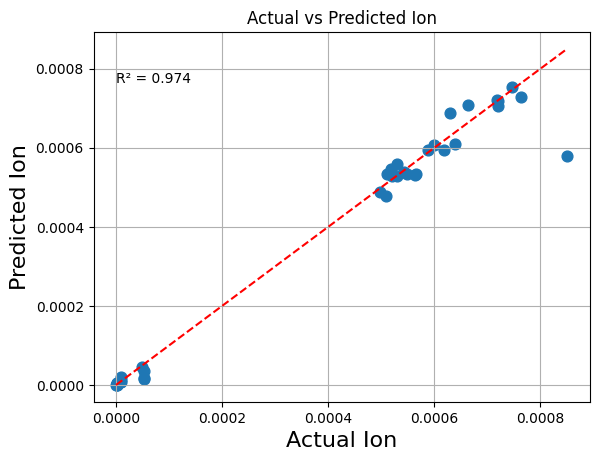


Running model for: SS
R2 Score (SS): 0.8949908200427108


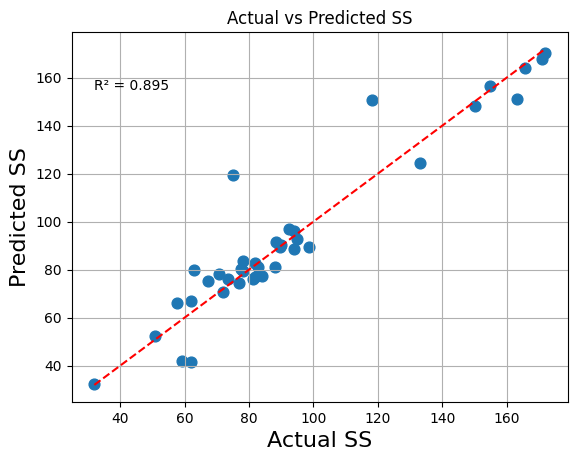

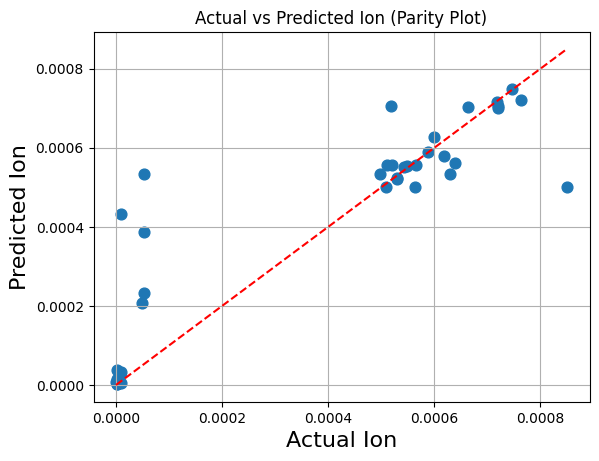


All analysis complete. Ready for transport-focused manuscript.


In [19]:
# ======================================================
# GAA FET Transport + ML Hybrid Framework (JOURNAL READY++)
# ======================================================

# Install if needed
# !pip install seaborn scikit-learn matplotlib pandas numpy shap xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBRegressor
import shap

# =============================
# 1. LOAD DATASET
# =============================
url = "https://raw.githubusercontent.com/MonikSense/GAAFET/refs/heads/main/GAA%20Dataset%20Final7.csv"
df = pd.read_csv(url)

df.columns = df.columns.str.strip()

# Rename
df.rename(columns={
    'Gate Self aligned': 'Gate',
    'Channel direction': 'Direction',
    'Lg (nm)': 'Lg',
    'Wns/Dnw (nm)': 'W',
    'SS (mV/dec)': 'SS',
    'Ion (A/um)': 'Ion'
}, inplace=True)

print(df.head())

# =============================
# 2. MONTE CARLO DATA AUGMENTATION
# =============================

# Generate synthetic data using Gaussian noise (Monte Carlo)
num_samples = len(df) * 3  # expand dataset (3x)
synthetic_data = []

for i in range(num_samples):
    sample = df.sample(1).copy()

    # Add small Gaussian noise (5%)
    for col in ['Lg', 'W', 'SS', 'Ion', 'Vov']:
        if col in sample.columns:
            noise = np.random.normal(0, 0.05 * sample[col].values[0])
            sample[col] = sample[col] + noise

    synthetic_data.append(sample)

synthetic_df = pd.concat(synthetic_data, ignore_index=True)

# Combine original + synthetic
augmented_df = pd.concat([df, synthetic_df], ignore_index=True)

print("Original size:", df.shape)
print("Augmented size:", augmented_df.shape)

# Use augmented dataset for further analysis
df = augmented_df

# =============================
# 3. FEATURE ENGINEERING
# =============================
df['Aspect_Ratio'] = df['W'] / df['Lg']
df['Electrostatic_Factor'] = df['Lg'] / df['W']
df['Effective_Field'] = df['Vov'] / df['Lg']

# =============================
# 3. DEFINE FEATURES & TARGET
# =============================
TARGET = 'Ion'
X = df.drop([TARGET], axis=1)
y = df[TARGET]

# =============================
# 4. SCALING
# =============================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =============================
# 5. TRAIN-TEST SPLIT
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

# =============================
# 6. MULTIPLE REGRESSION MODELS
# =============================
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.05),
    "SVR": SVR(),
    "KNN": KNeighborsRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}

results_summary = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results_summary.append([name, r2, rmse])

    # Prediction Efficiency
    efficiency = (1 - np.abs((y_test - y_pred)/y_test)).mean() * 100
    print(f"{name} Prediction Efficiency: {efficiency:.2f}%")

    # Predicted vs Actual
    plt.figure()
    plt.scatter(y_test, y_pred, s=60)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val],'r', linestyle='--')
    plt.xlabel("Actual Ion",fontsize=16)
    plt.ylabel("Predicted Ion",fontsize=16)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.title(f"{name}: Predicted vs Actual")
    plt.grid()
    plt.show()

# Comparison table
results_df = pd.DataFrame(results_summary, columns=["Model", "R2", "RMSE"])
print("\nModel Comparison:")
print(results_df)

# =============================
# 7. CLASSIFICATION (OPTIONAL HIGH/LOW PERFORMANCE)
# =============================
threshold = df['Ion'].median()
df['Ion_Class'] = (df['Ion'] > threshold).astype(int)

X_cls = df.drop(['Ion','Ion_Class'], axis=1)
y_cls = df['Ion_Class']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42)

clf = RandomForestClassifier()
clf.fit(X_train_c, y_train_c)
y_pred_c = clf.predict(X_test_c)

print("\nClassification Accuracy:", accuracy_score(y_test_c, y_pred_c))

# =============================
# 8. CORRELATION MATRIX
# =============================
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Matrix")
plt.show()

# =============================
# 9. FEATURE IMPORTANCE (RF)
# =============================
rf_model = models["Random Forest"]
importance = rf_model.feature_importances_
features = X.columns

plt.figure()
plt.barh(features, importance)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

# =============================
# 10. SHAP ANALYSIS
# =============================
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, feature_names=features)

# =============================
# 11. TRANSPORT ANALYSIS
# =============================

# Ion vs Lg
plt.figure()
plt.scatter(df['Lg'], df['Ion'])
plt.xlabel("Gate Length (Lg)")
plt.ylabel("Ion")
plt.title("Scaling Trend: Ion vs Lg")
plt.grid()
plt.show()

# SS vs W
plt.figure()
plt.scatter(df['W'], df['SS'])
plt.xlabel("Nanowire Width (W)")
plt.ylabel("Subthreshold Slope (SS)")
plt.title("SS vs Wns/Dnw")
plt.grid()
plt.show()

# Ion vs SS Trade-off
plt.figure()
plt.scatter(df['SS'], df['Ion'])
plt.xlabel("SS")
plt.ylabel("Ion")
plt.title("Ion vs SS Trade-off")
plt.grid()
plt.show()

# =============================
# 12. DISTRIBUTION
# =============================
plt.figure()
sns.histplot(df['Ion'], kde=True)
plt.title("Distribution of Ion")
plt.show()

# =============================
# 13. PAIRPLOT
# =============================
sns.pairplot(df[['Lg','W','SS','Ion','Vov']])
plt.show()


#========================
# FUNCTION TO TRAIN + PLOT
# =============================
def train_and_plot(target_name):

    print(f"\nRunning model for: {target_name}")

    X = df.drop([target_name], axis=1)
    y = df[target_name]

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42)

    model = RandomForestRegressor(n_estimators=200, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    print(f"R2 Score ({target_name}):", r2)

    # =============================
    # PARITY PLOT
    # =============================
    plt.figure()

    #plt.scatter(y_test, y_pred, alpha=0.7)
    plt.scatter(y_test, y_pred, s=60)

    # Diagonal line (y = x)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val],'r', linestyle='--')

    plt.xlabel(f"Actual {target_name}",fontsize=16)
    plt.ylabel(f"Predicted {target_name}",fontsize=16)
    plt.title(f"Actual vs Predicted {target_name}")
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    # Add R² text
    plt.text(min_val, max_val*0.9, f'R² = {r2:.3f}')

    plt.grid()
    plt.show()


# =============================
# RUN FOR BOTH TARGETS
# =============================
train_and_plot('Ion')
train_and_plot('SS')
# Plot
# =============================
# ACTUAL vs PREDICTED (Ion)
# =============================
plt.figure()

#plt.scatter(y_test, y_pred, alpha=0.7)
plt.scatter(y_test, y_pred, s=60)
# Diagonal line (perfect prediction)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],'r', linestyle='--')

plt.xlabel("Actual Ion",fontsize=16)
plt.ylabel("Predicted Ion",fontsize=16)
plt.title("Actual vs Predicted Ion (Parity Plot)")
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid()

plt.show()
# =============================
# 14. SAVE RESULTS
# =============================
pred_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted_RF': models['Random Forest'].predict(X_test)
})

pred_df.to_csv("prediction_results.csv", index=False)

print("\nAll analysis complete. Ready for transport-focused manuscript.")
